In [1]:
from irrigator.forecasts.arome_processing import (
    sync_static,
    sync_forecast,
    sync_dynamic,
    get_available_coverages,
    parse_coverage_id,
    find_available_run_dates,
    load_arome_daily_cache,
    ensure_dirs,
    DAILY_DIR,
    RAW_DIR,
)
from collections import defaultdict
import os

REPO_ROOT = os.path.dirname(os.getcwd())
os.chdir(REPO_ROOT)


results = sync_static(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")

results_dyn = sync_dynamic(overwrite=False)


results = sync_forecast(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")

    

2026-08-10 00:35:54,825 Syncing static archive...
2026-08-10 00:36:11,941 Retry 1/4 for DOWNWARD_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATE at 2026-08-09T00:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:37:07,377 Retry 1/4 for WIND_SPEED__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND___2 at 2026-08-08T09:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:37:40,581 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-08T03:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:37:55,375 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-08T12:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:37:56,417 Retry 2/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-08T12:00:00Z (HTTP 502, waiting 2s)
2026-08-10 00:38:29,929 Retry 1/4 for PRESSURE__GROUND_OR_WATER_SURFACE___2026-08-08T00. at 2026-08-08T02:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:38:45,122 Retry 1/4 for PRESSURE__GROUND_OR_WATER_SURFACE___2026-08-08T00. at 2026-08-08T11:00:00Z (HTTP 502, waiting 1s

  ✓ 2026-08-05: cached
  ✓ 2026-08-06: cached
  ✓ 2026-08-07: cached
  ↓ 2026-08-08: fetched
  ↓ 2026-08-09: fetched


2026-08-10 00:43:38,017 [dynamic] 2026-08-07T06: done
2026-08-10 00:44:01,186 [dynamic] 2026-08-07T09: done
2026-08-10 00:44:07,970 Retry 1/4 for TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND___ at 2026-08-07T14:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:44:14,422 Retry 1/4 for WIND_SPEED__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND___2 at 2026-08-07T14:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:44:18,632 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-07T12:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:44:21,214 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-07T13:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:44:30,200 [dynamic] 2026-08-07T12: done
2026-08-10 00:44:33,995 Retry 1/4 for TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND___ at 2026-08-07T15:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:44:48,675 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-07T17:00:00Z (HTTP 502, waiting 1s)
2026-08-10 00:44:52,85

  ✓ 2026-08-05: cached
  ✓ 2026-08-06: cached
  ✓ 2026-08-07: cached
  ↓ 2026-08-08: fetched
  ↓ 2026-08-09: fetched


# IFS

In [5]:
import os
import logging
from datetime import date, timedelta
from pathlib import Path
from irrigator.ingestion.ifs_ens_client import run_ifs_pipeline, load_ifs_daily

# Today only (default)
# daily_paths = run_ifs_pipeline()

# Or a date range:
daily_paths = run_ifs_pipeline(
    start=date(2026, 8, 5),
    end=date.today(),
    keep_raw=False,  # delete GRIBs after processing (default)
    #split_params=False
)

print(f"\nProcessed {len(daily_paths)} runs:")
for p in daily_paths:
    print(f"  {p.name}  ({p.stat().st_size / 1e6:.0f} MB)")


2026-08-10 10:20:40,255 IFS ENS 2026-08-05 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-05_00z.nc
2026-08-10 10:21:10,256 IFS ENS 2026-08-06 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-06_00z.nc
2026-08-10 10:21:40,266 [2026-08-07 00Z] Downloading...
2026-08-10 10:21:40,278 Downloading IFS ENS (bulk, source=ecmwf): 2026-08-07 00Z, 61 steps, 7 params
2026-08-10 10:21:40,279 To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.
2026-08-10 10:21:40,280 Unknown value 'ef' for keyword 'type'
2

<multiple>:   0%|          | 0.00/16.3G [00:00<?, ?B/s]

2026-08-10 10:45:08,013 Downloaded IFS ENS: data/raw/ifs_ens/ifs_ens_2026-08-07_00z.grib2 (17459.9 MB)
2026-08-10 10:45:08,013 [2026-08-07 00Z] Opening and slicing to bbox...


By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


2026-08-10 10:46:21,958 [2026-08-07 00Z] Processing to daily...
2026-08-10 10:53:37,129 IFS ENS daily: 16 days, 50 members, 8 variables
2026-08-10 10:53:39,013 Saved IFS ENS daily: data/processed/ifs_ens/ifs_daily_2026-08-07_00z.nc (46.1 MB, 50 members, 16 days)
2026-08-10 10:53:40,384 [2026-08-07 00Z] Deleted raw GRIB (17460 MB freed)
2026-08-10 10:54:10,395 [2026-08-08 00Z] Downloading...
2026-08-10 10:54:10,396 Downloading IFS ENS (bulk, source=ecmwf): 2026-08-08 00Z, 61 steps, 7 params
2026-08-10 10:54:46,395 Downloading <multiple>


...

<multiple>:   0%|          | 0.00/16.2G [00:00<?, ?B/s]

2026-08-10 11:48:09,695 Downloaded IFS ENS: data/raw/ifs_ens/ifs_ens_2026-08-09_00z.grib2 (17410.7 MB)
2026-08-10 11:48:09,696 [2026-08-09 00Z] Opening and slicing to bbox...
2026-08-10 11:50:31,349 [2026-08-09 00Z] Processing to daily...
2026-08-10 12:02:24,400 IFS ENS daily: 16 days, 50 members, 8 variables
2026-08-10 12:02:27,583 Saved IFS ENS daily: data/processed/ifs_ens/ifs_daily_2026-08-09_00z.nc (46.2 MB, 50 members, 16 days)
2026-08-10 12:02:30,028 [2026-08-09 00Z] Deleted raw GRIB (17411 MB freed)
2026-08-10 12:03:00,093 [2026-08-10 00Z] Downloading...
2026-08-10 12:03:00,096 Downloading IFS ENS (bulk, source=ecmwf): 2026-08-10 00Z, 61 steps, 7 params
2026-08-10 12:03:32,107 Downloading <multiple>


<multiple>:   0%|          | 0.00/16.2G [00:00<?, ?B/s]

2026-08-10 12:23:47,245 Downloaded IFS ENS: data/raw/ifs_ens/ifs_ens_2026-08-10_00z.grib2 (17432.5 MB)
2026-08-10 12:23:47,246 [2026-08-10 00Z] Opening and slicing to bbox...
2026-08-10 12:25:56,453 [2026-08-10 00Z] Processing to daily...
2026-08-10 12:37:42,576 IFS ENS daily: 16 days, 50 members, 8 variables
2026-08-10 12:37:45,645 Saved IFS ENS daily: data/processed/ifs_ens/ifs_daily_2026-08-10_00z.nc (46.3 MB, 50 members, 16 days)
2026-08-10 12:37:51,301 [2026-08-10 00Z] Deleted raw GRIB (17432 MB freed)
2026-08-10 12:37:51,344 IFS pipeline complete: 6/6 runs processed



Processed 6 runs:
  ifs_daily_2026-08-05_00z.nc  (46 MB)
  ifs_daily_2026-08-06_00z.nc  (46 MB)
  ifs_daily_2026-08-07_00z.nc  (46 MB)
  ifs_daily_2026-08-08_00z.nc  (46 MB)
  ifs_daily_2026-08-09_00z.nc  (46 MB)
  ifs_daily_2026-08-10_00z.nc  (46 MB)


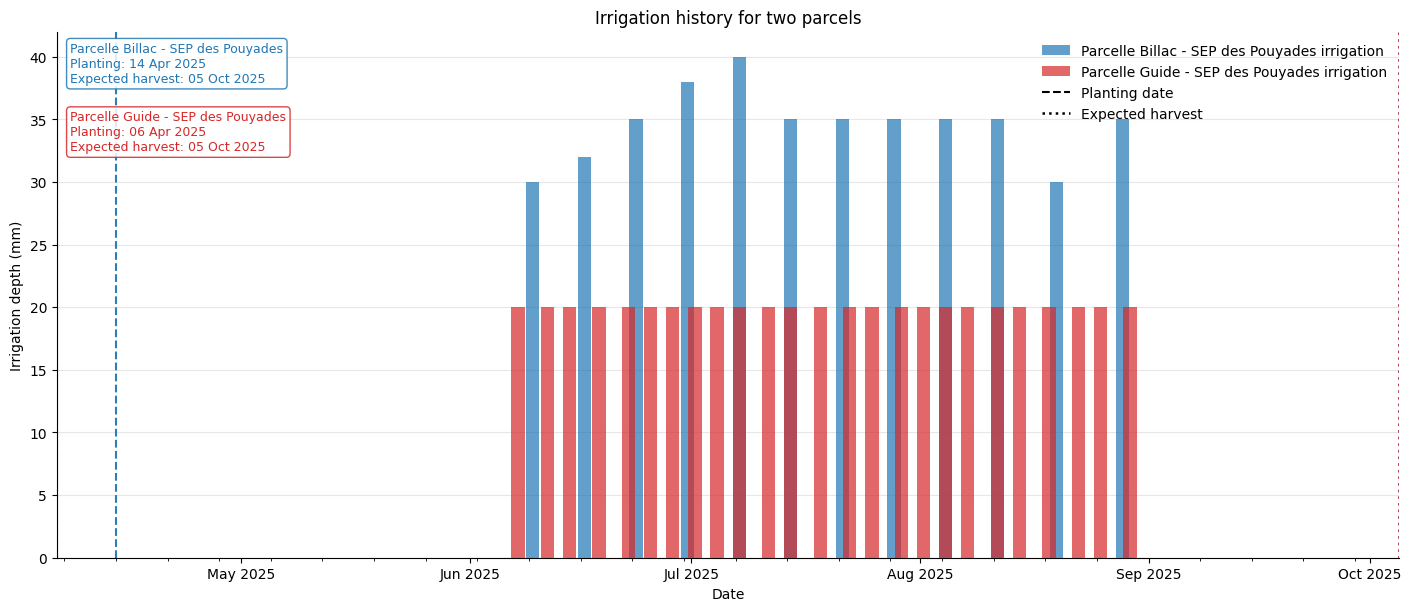

In [18]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import yaml


def read_parcel_irrigation(yaml_path: str | Path) -> dict:
    """Read one parcel YAML and return irrigation + crop season info."""
    yaml_path = Path(yaml_path)

    with yaml_path.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    parcel_name = cfg["parcel"]["name"]
    parcel_id = cfg["parcel"]["id"]

    planting_date = pd.Timestamp(cfg["crop"]["planting_date"])
    harvest_date = pd.Timestamp(cfg["crop"]["expected_harvest"])

    irrigation_raw = cfg.get("irrigation_log", [])

    if len(irrigation_raw) == 0:
        irrigation = pd.DataFrame(columns=["date", "amount_mm"])
    elif isinstance(irrigation_raw[0], dict):
        irrigation = pd.DataFrame(irrigation_raw)
        if "amount_mm" not in irrigation.columns:
            for candidate in ["amount", "mm", "depth_mm"]:
                if candidate in irrigation.columns:
                    irrigation = irrigation.rename(columns={candidate: "amount_mm"})
                    break
    else:
        irrigation = pd.DataFrame(irrigation_raw, columns=["date", "amount_mm"])

    if not irrigation.empty:
        irrigation["date"] = pd.to_datetime(irrigation["date"])
        irrigation["amount_mm"] = pd.to_numeric(irrigation["amount_mm"])
        irrigation = irrigation.sort_values("date")

        irrigation = irrigation.loc[
            irrigation["date"].between(planting_date, harvest_date, inclusive="both")
        ].copy()

    return {
        "name": parcel_name,
        "id": parcel_id,
        "planting_date": planting_date,
        "harvest_date": harvest_date,
        "irrigation": irrigation,
    }


def plot_two_parcels_same_axis(yaml_a, yaml_b, bar_width_days=1.8):
    """Plot irrigation logs for two parcels on the same axis."""
    parcel_a = read_parcel_irrigation(yaml_a)
    parcel_b = read_parcel_irrigation(yaml_b)

    parcels = [parcel_a, parcel_b]
    colors = ["tab:blue", "tab:red"]
    offsets = [pd.Timedelta(hours=-12), pd.Timedelta(hours=12)]

    fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

    for parcel, color, offset in zip(parcels, colors, offsets):
        irr = parcel["irrigation"]

        if not irr.empty:
            ax.bar(
                irr["date"] + offset,
                irr["amount_mm"],
                width=bar_width_days,
                alpha=0.70,
                color=color,
                label=f"{parcel['name']} irrigation",
                zorder=3,
            )

        # Keep date markers, but do not write text directly at those dates
        ax.axvline(
            parcel["planting_date"],
            color=color,
            linestyle="--",
            linewidth=1.5,
            alpha=0.95,
            zorder=2,
        )
        ax.axvline(
            parcel["harvest_date"],
            color=color,
            linestyle=":",
            linewidth=1.8,
            alpha=0.95,
            zorder=2,
        )

    xmin = min(parcel_a["planting_date"], parcel_b["planting_date"])
    xmax = max(parcel_a["harvest_date"], parcel_b["harvest_date"])
    ax.set_xlim(xmin, xmax)

    ax.set_title("Irrigation history for two parcels")
    ax.set_xlabel("Date")
    ax.set_ylabel("Irrigation depth (mm)")

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Main legend for bars
    bar_handles, bar_labels = ax.get_legend_handles_labels()

    # Secondary legend entries for line styles
    style_handles = [
        Line2D([0], [0], color="black", linestyle="--", lw=1.5, label="Planting date"),
        Line2D([0], [0], color="black", linestyle=":", lw=1.8, label="Expected harvest"),
    ]

    ax.legend(
        handles=bar_handles + style_handles,
        loc="upper right",
        frameon=False,
    )

    # Put parcel date information in clean corner text boxes
    text_a = (
        f"{parcel_a['name']}\n"
        f"Planting: {parcel_a['planting_date']:%d %b %Y}\n"
        f"Expected harvest: {parcel_a['harvest_date']:%d %b %Y}"
    )
    text_b = (
        f"{parcel_b['name']}\n"
        f"Planting: {parcel_b['planting_date']:%d %b %Y}\n"
        f"Expected harvest: {parcel_b['harvest_date']:%d %b %Y}"
    )

    ax.text(
        0.01,
        0.98,
        text_a,
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=colors[0],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor=colors[0]),
    )

    ax.text(
        0.01,
        0.85,
        text_b,
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=colors[1],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor=colors[1]),
    )

    return fig, ax



# ---------------------------------------------------------------------
# Usage
# ---------------------------------------------------------------------

yaml_files = [
    Path("/home/mbaldacchino/data/IrriGator_safe/configs/parcels/billac_2025.yaml"),
    Path("/home/mbaldacchino/data/IrriGator_safe/configs/parcels/guide_2025.yaml"),
]

fig, axes = plot_two_parcels_same_axis(*yaml_files)

# Optional export:
# fig.savefig(
#     "irrigation_history_2025.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()
